In [22]:
import pandas as pd
import numpy as np
import optuna

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [2]:
train = pd.read_csv('train.csv')

test = pd.read_csv('test.csv')

In [3]:
train.head()

,id,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,0,e,8.80,f,s,u,f,a,c,w,...,NaN,NaN,w,NaN,NaN,f,f,NaN,d,a
1,1,p,4.51,x,h,o,f,a,c,n,...,NaN,y,o,NaN,NaN,t,z,NaN,d,w
2,2,e,6.94,f,s,b,f,x,c,w,...,NaN,s,n,NaN,NaN,f,f,NaN,l,w
3,3,e,3.88,f,y,g,f,s,NaN,g,...,NaN,NaN,w,NaN,NaN,f,f,NaN,d,u
4,4,e,5.85,x,l,w,f,d,NaN,w,...,NaN,NaN,w,NaN,NaN,f,f,NaN,g,a


In [4]:
train.isnull().sum()

id                            0
class                         0
cap-diameter                  4
cap-shape                    40
cap-surface              671023
cap-color                    12
does-bruise-or-bleed          8
gill-attachment          523936
gill-spacing            1258435
gill-color                   57
stem-height                   0
stem-width                    0
stem-root               2757023
stem-surface            1980861
stem-color                   38
veil-type               2957493
veil-color              2740947
has-ring                     24
ring-type                128880
spore-print-color       2849682
habitat                      45
season                        0
dtype: int64

In [5]:
drop_cols = ["veil-type", "veil-color", "stem-root", "stem-surface", "spore-print-color", 'cap-surface', 'gill-attachment', 'gill-spacing', 'ring-type']

In [6]:
train = train.drop(columns=drop_cols)

In [7]:
train.isnull().sum()

id                       0
class                    0
cap-diameter             4
cap-shape               40
cap-color               12
does-bruise-or-bleed     8
gill-color              57
stem-height              0
stem-width               0
stem-color              38
has-ring                24
habitat                 45
season                   0
dtype: int64

In [8]:
train.duplicated().sum()

0

In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3116945 entries, 0 to 3116944
Data columns (total 13 columns):
 #   Column                Dtype  
---  ------                -----  
 0   id                    int64  
 1   class                 object 
 2   cap-diameter          float64
 3   cap-shape             object 
 4   cap-color             object 
 5   does-bruise-or-bleed  object 
 6   gill-color            object 
 7   stem-height           float64
 8   stem-width            float64
 9   stem-color            object 
 10  has-ring              object 
 11  habitat               object 
 12  season                object 
dtypes: float64(3), int64(1), object(9)
memory usage: 309.1+ MB


In [10]:
test = test.drop(columns=drop_cols)

In [11]:
X = train.drop(columns=["id", "class"])
X_test_final = test.drop(columns=["id"])

In [12]:
# Encode target
le = LabelEncoder()
y = le.fit_transform(train["class"])  # 'e' -> 0, 'p' -> 1

In [13]:
# ===============================
# 3. Train/Validation Split
# ===============================
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [14]:
# ===============================
# 4. Define Preprocessing
# ===============================
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(include=["float64", "int64"]).columns

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", categorical_transformer, categorical_cols),
        ("numerical", numerical_transformer, numerical_cols)
    ]
)

In [15]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False])
    }
    
    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(**params, random_state=42))
    ])
    
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring="accuracy")
    return scores.mean()

In [16]:
# 6. Run Optuna
# ===============================
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)  # increase n_trials for better tuning

[I 2025-09-13 20:22:04,571] A new study created in memory with name: no-name-520e053b-149a-4f39-b4d3-8121872a1cb4
[W 2025-09-13 20:35:39,999] Trial 0 failed with parameters: {'n_estimators': 339, 'max_depth': 4, 'min_samples_split': 16, 'min_samples_leaf': 20, 'bootstrap': False} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "d:\anaconda3\Lib\site-packages\optuna\study\_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\Dell\AppData\Local\Temp\ipykernel_3708\112688396.py", line 15, in objective
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring="accuracy")
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\anaconda3\Lib\site-packages\sklearn\utils\_param_validation.py", line 218, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "d:\anaconda3\Lib\site-packages\sklearn\model_sel

KeyboardInterrupt: 


=== Logistic Regression ===
Validation ROC-AUC: 0.6513
Best Threshold (Youden's J): 0.5426
Accuracy (threshold 0.5): 0.6202756224444127
Accuracy (optimal threshold): 0.6200430228958163

Classification Report (optimal threshold):
              precision    recall  f1-score   support

           0       0.58      0.57      0.58    282310
           1       0.65      0.66      0.66    341079

    accuracy                           0.62    623389
   macro avg       0.62      0.62      0.62    623389
weighted avg       0.62      0.62      0.62    623389

Confusion Matrix:
 [[161278 121032]
 [115829 225250]]

=== Random Forest ===
Validation ROC-AUC: 0.8835
Best Threshold (Youden's J): 0.5124
Accuracy (threshold 0.5): 0.796278086395493
Accuracy (optimal threshold): 0.7988944302834987

Classification Report (optimal threshold):
              precision    recall  f1-score   support

           0       0.77      0.80      0.78    282310
           1       0.83      0.80      0.81    341079

  

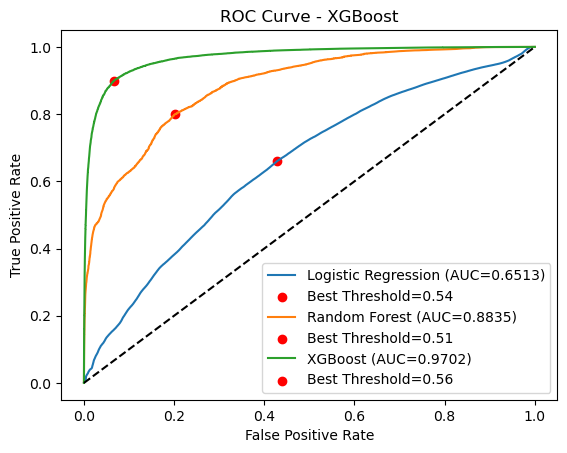

In [23]:
models = {
    "Logistic Regression": LogisticRegression(solver='liblinear', penalty='l2', random_state=42, max_iter=1500),
    "Random Forest": RandomForestClassifier(n_estimators=300,max_depth= 5,random_state=42),
    "XGBoost": XGBClassifier(learning_rate=0.3, max_depth=3, random_state=42)
}

for name, model in models.items():

    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor), 
        ('clf', model)
    ])

    # Fit on oversampled training set
    pipe.fit(X_train, y_train)

    # Validation predictions (for threshold)
    y_proba = pipe.predict_proba(X_valid)[:,1]

    # Validation predictions (for default =0.5)
    y_pred = pipe.predict(X_valid)

    # ROC-AUC & Optimal Threshold

    fpr, tpr, threshold = roc_curve(y_valid, y_proba) 
    auc = roc_auc_score(y_valid, y_proba)

    j_scores = tpr - fpr 
    best_idx = np.argmax(j_scores)
    best_thresh = threshold[best_idx]

    # Apply optimal Threshold 

    y_pred_opt = (y_proba >= best_thresh).astype(int)

    print(f"\n=== {name} ===")
    print(f"Validation ROC-AUC: {auc:.4f}")
    print(f"Best Threshold (Youden's J): {best_thresh:.4f}")
    print("Accuracy (threshold 0.5):", accuracy_score(y_valid, y_pred))
    print("Accuracy (optimal threshold):", accuracy_score(y_valid, y_pred_opt))
    print("\nClassification Report (optimal threshold):")
    print(classification_report(y_valid, y_pred_opt))
    print("Confusion Matrix:\n", confusion_matrix(y_valid, y_pred_opt))

    # Plot ROC curve with best threshold point

    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.4f})")
    plt.scatter(fpr[best_idx], tpr[best_idx], color='red', label=f"Best Threshold={best_thresh:.2f}")

# Plot ROC curve

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - {name}")
plt.legend()
plt.show()

In [24]:
final_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", XGBClassifier(learning_rate=0.3, max_depth=3, random_state=42))
])

In [25]:
final_pipe.fit(X, y)

,steps,"[('preprocessor', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...), ('numerical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [26]:
# Using Optimal Threshold
y_test_proba = final_pipe.predict_proba(X_test_final)[:,1]
y_final_pred = (y_test_proba >= best_thresh).astype(int)

# Using 0.5 default Threshold
y_default_pred = final_pipe.predict(X_test_final)

In [27]:
y_pred_labels = le.inverse_transform(y_final_pred)  # back to 'e' / 'p'

In [28]:
submission = pd.DataFrame({
    "id": test["id"],
    "class": y_pred_labels
})

submission.to_csv("submission.csv", index=False)
print("✅ submission.csv file created with labels (e/p)")

✅ submission.csv file created with labels (e/p)
